#### Week 6 Assignment: Prediction Shootout + Project Proposal
#### 第 6 週作業：空間預測對決 + 期末專案提案

1. 任務情境 (Scenario)
指揮官說：「不同類型的降雨事件，空間分布完全不同。你能用同一套工具分析不同事件嗎？哪種方法在什麼情境下表現最好？」

#### Part A：自選兩個降雨事件，分別執行 Kriging vs Random Forest 的完整比較，並分析兩事件的 Variogram 差異


#### A0. 資料蒐集（重要！）

1. 前往 [CoLife 歷史資料庫](https://history.colife.org.tw/#/?cd=%2F%E6%B0%A3%E8%B1%A1%2F%E4%B8%AD%E5%A4%AE%E6%B0%A3%E8%B1%A1%E7%BD%B2_%E9%9B%A8%E9%87%8F%E7%AB%99) → 氣象 → 中央氣象署_雨量站
2. **自選兩個不同的降雨事件**，下載對應月份的雨量資料：
   - 康芮颱風：2024/10/29 23:00
   - 豪雨事件：2025/07/28 23:00
3. 兩個事件應具有**不同的降雨特性**，例如：  
   - **颱風（集中型強降雨） vs 豪雨（相對分散型降雨）**

   根據四種內插結果可看出，**鳳凰颱風事件**的高雨量區主要集中在研究區東北側，且蘇澳附近出現非常明顯的局部高值核心，無論是 IDW、Kriging 或 RF，都呈現出較強的單一熱區特徵，顯示其降雨具有**集中型、局部極端值突出、空間分布高度不均**的特性，屬於典型颱風型強降雨。  
   
   相較之下，**豪雨事件**的高雨量分布較為分散，在研究區南段、中段與北段皆可見多個次高值區，NN 與 IDW 結果也呈現多個降雨中心，而非單一核心；Kriging 雖然平滑後較不明顯，但整體仍反映出**多點分布、局部熱區較多、降雨場較破碎**的特徵，較接近豪雨事件常見的分散型降雨型態。  
   
   因此，兩事件在空間降雨結構上具有明顯差異：**鳳凰颱風偏向集中型強降雨，豪雨事件則偏向相對分散、局部多核心的降雨型態**，符合本作業要求的「不同降雨特性」。
> **提示**：[全民防災 e 點通 — 歷年災害專區](https://bear.emic.gov.tw/MY2/disasterInfo) 可查詢歷年颱風與豪雨事件紀錄，幫助你挑選事件。

4. 每個事件篩選**花蓮縣+宜蘭縣**測站，過濾 -998 / 0 值
5. 轉為 EPSG:3826（**Kriging 必須使用公尺座標**）

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

# =========================================================
# A0. 事件資料前處理
# - 讀取 CSV
# - 統一時間欄位
# - 篩選 花蓮縣 + 宜蘭縣
# - 過濾 -998 / 0 值
# - 轉為 GeoDataFrame
# - 投影到 EPSG:3826
# =========================================================

def load_and_prepare_event_csv(csv_path, event_name):
    """
    讀取單一事件 CSV，完成 HW6 A0 前處理：
    1. 統一時間欄位名稱為 obs_time
    2. 篩選花蓮縣 + 宜蘭縣
    3. 過濾 rain_1hr 的 -998 / 0 / NaN
    4. 建立 GeoDataFrame (EPSG:4326)
    5. 轉投影到 EPSG:3826

    回傳：
    - df_clean: 清理後 DataFrame
    - gdf_4326: WGS84 GeoDataFrame
    - gdf_3826: EPSG:3826 GeoDataFrame
    """
    df_raw = pd.read_csv(csv_path)
    df = df_raw.copy()

    # -----------------------------------------------------
    # 1. 統一時間欄位
    # -----------------------------------------------------
    if "phenomenonTime" in df.columns:
        df = df.rename(columns={"phenomenonTime": "obs_time"})
    elif "DateTime" in df.columns:
        df = df.rename(columns={"DateTime": "obs_time"})
    else:
        raise ValueError(f"{event_name}: 找不到時間欄位（phenomenonTime / DateTime）")

    df["obs_time"] = pd.to_datetime(df["obs_time"], errors="coerce")

    # -----------------------------------------------------
    # 2. 統一主要欄位名稱
    # -----------------------------------------------------
    rename_map = {
        "StationId": "station_id",
        "StationName": "station_name",
        "CountyName": "county",
        "TownName": "town",
        "StationLatitude": "lat",
        "StationLongitude": "lon",
        "StationAltitude": "altitude",
        "Past10Min": "rain_10min",
        "Past1hr": "rain_1hr",
        "Past3hr": "rain_3hr",
        "Past6hr": "rain_6hr",
        "Past12hr": "rain_12hr",
        "Past24hr": "rain_24hr",
        "NOW": "rain_now"
    }
    df = df.rename(columns=rename_map)

    # -----------------------------------------------------
    # 3. 檢查必要欄位是否存在
    # -----------------------------------------------------
    required_cols = ["station_id", "station_name", "county", "town", "lon", "lat", "rain_1hr", "obs_time"]
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{event_name}: 缺少必要欄位 {missing_cols}")

    # -----------------------------------------------------
    # 4. 轉數值
    # -----------------------------------------------------
    numeric_cols = ["lon", "lat", "rain_1hr"]
    optional_numeric_cols = ["altitude", "rain_10min", "rain_3hr", "rain_6hr", "rain_12hr", "rain_24hr", "rain_now"]

    for col in numeric_cols + optional_numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # -----------------------------------------------------
    # 5. 篩選 花蓮縣 + 宜蘭縣
    # -----------------------------------------------------
    df = df[df["county"].isin(["花蓮縣", "宜蘭縣"])].copy()

    # -----------------------------------------------------
    # 6. 過濾無效值：-998 / 0 / NaN
    # -----------------------------------------------------
    df = df.dropna(subset=["lon", "lat", "rain_1hr", "obs_time"]).copy()
    df = df[(df["rain_1hr"] != -998) & (df["rain_1hr"] > 0)].copy()

    # -----------------------------------------------------
    # 7. 建立 GeoDataFrame (EPSG:4326)
    # -----------------------------------------------------
    gdf_4326 = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326"
    )

    # -----------------------------------------------------
    # 8. 轉為 EPSG:3826
    # -----------------------------------------------------
    gdf_3826 = gdf_4326.to_crs(epsg=3826)

    # -----------------------------------------------------
    # 9. 印出基本資訊
    # -----------------------------------------------------
    print(f"\n========== {event_name} ==========")
    print(f"原始筆數：{len(df_raw):,}")
    print(f"花蓮+宜蘭 且 rain_1hr > 0 後筆數：{len(gdf_3826):,}")
    print(f"時間範圍：{gdf_3826['obs_time'].min()} ~ {gdf_3826['obs_time'].max()}")
    print(f"可用時刻數：{gdf_3826['obs_time'].nunique():,}")
    print(f"CRS：{gdf_3826.crs}")

    print("\n前 5 筆資料：")
    show_cols = ["station_name", "county", "town", "obs_time", "rain_1hr", "lon", "lat"]
    print(gdf_3826[show_cols].head().to_string(index=False))

    print("\n各時刻測站數（前 10 個時刻）：")
    time_counts = (
        gdf_3826.groupby("obs_time")
        .size()
        .reset_index(name="n_stations")
        .sort_values("obs_time")
    )
    print(time_counts.head(10).to_string(index=False))

    return df, gdf_4326, gdf_3826


# =========================================================
# 載入兩個事件
# =========================================================
fungwong_df, fungwong_gdf_4326, fungwong_gdf_3826 = load_and_prepare_event_csv(
    "..\\data\\rain_20251111.csv",
    "2025-11-11 鳳凰颱風"
)

heavy_df, heavy_gdf_4326, heavy_gdf_3826 = load_and_prepare_event_csv(
    "..\\data\\rain_20250728.csv",
    "2025-07-28 豪雨事件"
)


========== 2025-11-11 鳳凰颱風 ==========
原始筆數：180,336
花蓮+宜蘭 且 rain_1hr > 0 後筆數：19,304
時間範圍：2025-11-11 00:00:00 ~ 2025-11-12 00:00:00
可用時刻數：143
CRS：EPSG:3826

前 5 筆資料：
station_name county town   obs_time  rain_1hr        lon       lat
          宜蘭    宜蘭縣  宜蘭市 2025-11-11       1.5 121.756528 24.763975
          花蓮    花蓮縣  花蓮市 2025-11-11       4.0 121.613275 23.975128
         合歡山    花蓮縣  秀林鄉 2025-11-11       0.5 121.284231 24.143186
          寒溪    宜蘭縣  冬山鄉 2025-11-11       2.0 121.716908 24.634003
         雙連埤    宜蘭縣  員山鄉 2025-11-11       3.0 121.641303 24.753033

各時刻測站數（前 10 個時刻）：
           obs_time  n_stations
2025-11-11 00:00:00         169
2025-11-11 00:10:00         168
2025-11-11 00:20:00         167
2025-11-11 00:30:00         167
2025-11-11 00:40:00         166
2025-11-11 00:50:00         166
2025-11-11 01:00:00         163
2025-11-11 01:10:00         165
2025-11-11 01:20:00         168
2025-11-11 01:30:00         168

========== 2025-07-28 豪雨事件 ==========
原始筆數：172,032
花蓮+宜蘭 且 ra

In [2]:
#指定雨量時間
fungwong_t = fungwong_gdf_3826[fungwong_gdf_3826["obs_time"] == pd.Timestamp("2025-11-11 18:50:00")].copy()
print(fungwong_t.shape)
heavy_t = heavy_gdf_3826[heavy_gdf_3826["obs_time"] == pd.Timestamp("2025-07-28 17:10:00")].copy()
print(heavy_t.shape)

(89, 18)
(90, 18)


#### A1. Variogram 分析（兩個事件各做一次）

1. 對每個事件分別建立至少 **2 種 Variogram 模型**（如 spherical + exponential），比較擬合結果
2. 產出 **Variogram 比較圖**：實驗點 + 兩種擬合曲線
3. 選擇最佳模型，**說明選擇理由**（1-2 句）
4. **比較兩事件的 Variogram 參數差異**（Sill、Range、Nugget），用 1-2 句解釋為什麼不同
   - 提示：回想課堂 Slide 4 的口訣「Sill 看天氣、Nugget 看儀器、Range 看地理」

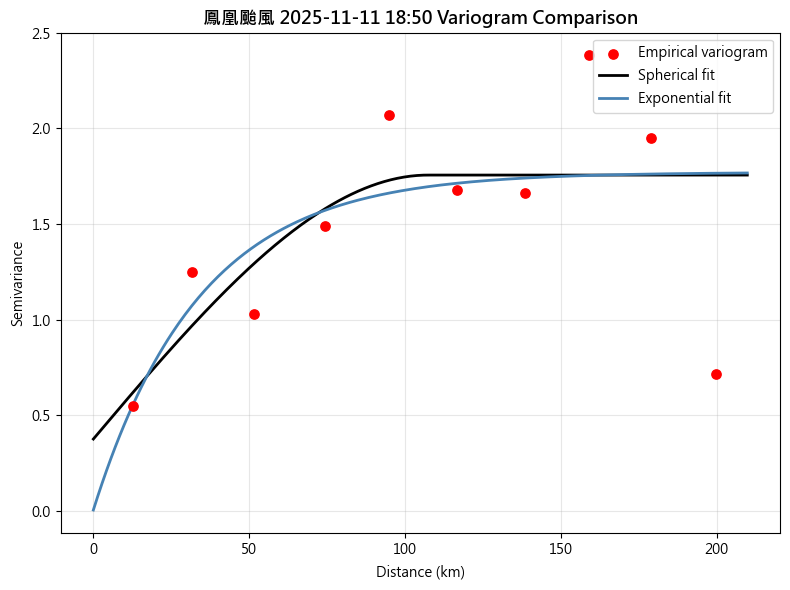


========== 鳳凰颱風 2025-11-11 18:50 ==========
測站數：89
分析時刻：2025-11-11 18:50:00

Variogram model comparison:


,event,model,sill,range_m,range_km,nugget,SSE
0,鳳凰颱風 2025-11-11 18:50,spherical,1.3806,107403,107.40,0.3752,1.803306
1,鳳凰颱風 2025-11-11 18:50,exponential,1.7663,102129,102.13,0.0041,1.866616



最佳模型：spherical
選擇理由：spherical model 的 SSE 最小，表示其 fitted curve 與 empirical variogram 點的貼合度較佳，因此較適合作為此事件的 variogram model。


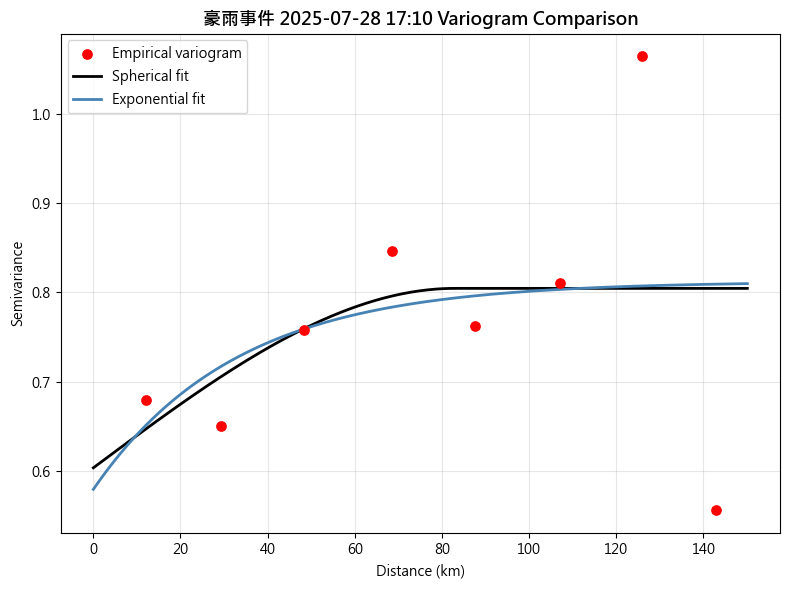


========== 豪雨事件 2025-07-28 17:10 ==========
測站數：90
分析時刻：2025-07-28 17:10:00

Variogram model comparison:


,event,model,sill,range_m,range_km,nugget,SSE
0,豪雨事件 2025-07-28 17:10,spherical,0.2006,82953,82.95,0.6039,0.137159
1,豪雨事件 2025-07-28 17:10,exponential,0.2324,98205,98.20,0.5798,0.140045



最佳模型：spherical
選擇理由：spherical model 的 SSE 最小，表示其 fitted curve 與 empirical variogram 點的貼合度較佳，因此較適合作為此事件的 variogram model。

========== 兩事件 Variogram 參數比較 ==========


,參數,鳳凰颱風 2025-11-11 18:50,豪雨事件 2025-07-28 17:10
0,Best Model,spherical,spherical
1,Sill,1.381,0.201
2,Range (km),107.403,82.953
3,Nugget,0.375,0.604



========== 可直接參考的文字解釋 ==========

[事件 1 最佳模型理由]
鳳凰颱風事件以 spherical variogram model 的擬合效果最佳，因其 SSE 最小，代表模型曲線與 empirical variogram 點的貼合程度較高，較能反映該時刻雨量測站之間的空間相依結構。

[事件 2 最佳模型理由]
豪雨事件以 spherical variogram model 的擬合效果最佳，因其 SSE 較小，表示此模型較能描述該事件的空間變異特性。

[兩事件參數差異解釋]
鳳凰颱風事件的 sill 較大，表示整體雨量空間變異較強，可能反映局部極端降雨與周圍測站差異較大，亦即『Sill 看天氣』。
鳳凰颱風事件的 range 較大，表示空間相關延伸得更遠，雨量分布較可能具有區域一致性，亦即『Range 看地理』。
豪雨事件的 nugget 較大，可能表示短距離變異較強，或觀測值受局部微尺度降雨與儀器誤差影響較明顯，亦即『Nugget 看儀器』。


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from matplotlib import font_manager, rcParams

# =========================================================
# A1. Variogram 分析（兩個事件各做一次）
# - 自動擬合 variogram（不手動指定 sill/range/nugget）
# - 比較 spherical / exponential
# - 繪製 empirical variogram + fitted curves
# - 選擇最佳模型（以 SSE 最小為主）
# - 比較兩事件的 Sill / Range / Nugget
# =========================================================


# ---------------------------------------------------------
# 0. 設定 matplotlib 中文字型，避免圖上中文亂碼
# ---------------------------------------------------------
candidate_fonts = [
    "Microsoft JhengHei", "PingFang TC", "Noto Sans CJK TC",
    "Noto Sans CJK JP", "SimHei", "Arial Unicode MS"
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
for f in candidate_fonts:
    if f in available_fonts:
        rcParams["font.sans-serif"] = [f]
        break
rcParams["axes.unicode_minus"] = False


# ---------------------------------------------------------
# 1. 先指定兩個事件要分析的時刻
#    請依你的資料實際情況修改時間
# ---------------------------------------------------------
fungwong_t = fungwong_gdf_3826[
    fungwong_gdf_3826["obs_time"] == pd.Timestamp("2025-11-11 18:50:00")
].copy()

heavy_t = heavy_gdf_3826[
    heavy_gdf_3826["obs_time"] == pd.Timestamp("2025-07-28 17:10:00")
].copy()


# ---------------------------------------------------------
# 2. 單一事件 variogram 分析函式
# ---------------------------------------------------------
def analyze_variogram_for_event(gdf_event, event_name, nlags=10):
    """
    對單一事件進行 variogram 分析：
    1. 取 x, y, z
    2. 對 z 做 log1p
    3. 比較 spherical / exponential（自動擬合）
    4. 繪製 empirical variogram + fitted curves
    5. 以 SSE 最小選擇最佳模型

    回傳：
    {
        "event_name": ...,
        "x": x,
        "y": y,
        "z": z,
        "z_log": z_log,
        "results_df": results_df,
        "best_model": ...,
        "best_ok": ...
    }
    """

    if gdf_event.empty:
        raise ValueError(f"{event_name} 沒有資料，請確認你挑選的分析時刻是否有有效測站。")

    if len(gdf_event) < 5:
        raise ValueError(f"{event_name} 測站數只有 {len(gdf_event)}，太少，不適合做穩定的 variogram 分析。")

    # 取 x, y, z
    x = gdf_event.geometry.x.values
    y = gdf_event.geometry.y.values
    z = gdf_event["rain_1hr"].values.astype(float)

    # log-transform（延續 exercise6 邏輯）
    z_log = np.log1p(z)

    model_list = ["spherical", "exponential"]
    results = []
    ok_objects = {}

    # 逐一 model 自動擬合
    for model_name in model_list:
        ok = OrdinaryKriging(
            x, y, z_log,
            variogram_model=model_name,
            verbose=False,
            enable_plotting=False,
            nlags=nlags
        )

        params = ok.variogram_model_parameters
        lags = ok.lags
        semivariance = ok.semivariance

        fitted_at_lags = ok.variogram_function(params, lags)
        sse = float(np.sum((semivariance - fitted_at_lags) ** 2))

        results.append({
            "event": event_name,
            "model": model_name,
            "sill": float(params[0]),
            "range_m": float(params[1]),
            "range_km": float(params[1] / 1000.0),
            "nugget": float(params[2]),
            "SSE": sse
        })

        ok_objects[model_name] = ok

    results_df = pd.DataFrame(results).sort_values("SSE").reset_index(drop=True)
    best_model = results_df.loc[0, "model"]
    best_ok = ok_objects[best_model]

    # ---------- 畫圖 ----------
    empirical_lags_km = best_ok.lags / 1000.0
    empirical_semivar = best_ok.semivariance

    max_dist = np.max(best_ok.lags) * 1.05
    dist_line = np.linspace(0, max_dist, 300)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        empirical_lags_km,
        empirical_semivar,
        c="red",
        s=45,
        label="Empirical variogram",
        zorder=3
    )

    color_map = {
        "spherical": "black",
        "exponential": "steelblue"
    }

    for model_name in model_list:
        ok = ok_objects[model_name]
        params = ok.variogram_model_parameters
        curve = ok.variogram_function(params, dist_line)

        plt.plot(
            dist_line / 1000.0,
            curve,
            color=color_map[model_name],
            linewidth=2,
            label=f"{model_name.capitalize()} fit"
        )

    plt.title(f"{event_name} Variogram Comparison", fontsize=13, fontweight="bold")
    plt.xlabel("Distance (km)")
    plt.ylabel("Semivariance")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------- 顯示數值結果 ----------
    print(f"\n========== {event_name} ==========")
    print(f"測站數：{len(gdf_event)}")
    print(f"分析時刻：{gdf_event['obs_time'].iloc[0]}")
    print("\nVariogram model comparison:")

    display(
        results_df.style.format({
            "sill": "{:.4f}",
            "range_m": "{:.0f}",
            "range_km": "{:.2f}",
            "nugget": "{:.4f}",
            "SSE": "{:.6f}"
        })
    )

    print(f"\n最佳模型：{best_model}")
    print(
        f"選擇理由：{best_model} model 的 SSE 最小，表示其 fitted curve "
        f"與 empirical variogram 點的貼合度較佳，因此較適合作為此事件的 variogram model。"
    )

    return {
        "event_name": event_name,
        "x": x,
        "y": y,
        "z": z,
        "z_log": z_log,
        "results_df": results_df,
        "best_model": best_model,
        "best_ok": best_ok
    }


# ---------------------------------------------------------
# 3. 分析兩個事件
# ---------------------------------------------------------
fungwong_vario = analyze_variogram_for_event(
    fungwong_t,
    "鳳凰颱風 2025-11-11 18:50",
    nlags=10
)

heavy_vario = analyze_variogram_for_event(
    heavy_t,
    "豪雨事件 2025-07-28 17:10",
    nlags=8
)


# ---------------------------------------------------------
# 4. 比較兩事件最佳模型的參數差異
# ---------------------------------------------------------
fungwong_best = fungwong_vario["results_df"].iloc[0].copy()
heavy_best = heavy_vario["results_df"].iloc[0].copy()

compare_df = pd.DataFrame({
    "參數": ["Best Model", "Sill", "Range (km)", "Nugget"],
    "鳳凰颱風 2025-11-11 18:50": [
        fungwong_best["model"],
        fungwong_best["sill"],
        fungwong_best["range_km"],
        fungwong_best["nugget"]
    ],
    "豪雨事件 2025-07-28 17:10": [
        heavy_best["model"],
        heavy_best["sill"],
        heavy_best["range_km"],
        heavy_best["nugget"]
    ]
})

# 只格式化數值列，避免 Best Model 那列字串報錯
compare_df_fmt = compare_df.copy()
for col in ["鳳凰颱風 2025-11-11 18:50", "豪雨事件 2025-07-28 17:10"]:
    compare_df_fmt.loc[1:, col] = (
        compare_df_fmt.loc[1:, col]
        .astype(float)
        .map(lambda x: f"{x:.3f}")
    )

print("\n========== 兩事件 Variogram 參數比較 ==========")
display(compare_df_fmt)


# ---------------------------------------------------------
# 5. 自動產生可直接寫進作業的簡短解釋
# ---------------------------------------------------------
fungwong_sill = float(fungwong_best["sill"])
heavy_sill = float(heavy_best["sill"])

fungwong_range = float(fungwong_best["range_km"])
heavy_range = float(heavy_best["range_km"])

fungwong_nugget = float(fungwong_best["nugget"])
heavy_nugget = float(heavy_best["nugget"])

print("\n========== 可直接參考的文字解釋 ==========")

print("\n[事件 1 最佳模型理由]")
print(
    f"鳳凰颱風事件以 {fungwong_best['model']} variogram model 的擬合效果最佳，"
    f"因其 SSE 最小，代表模型曲線與 empirical variogram 點的貼合程度較高，"
    f"較能反映該時刻雨量測站之間的空間相依結構。"
)

print("\n[事件 2 最佳模型理由]")
print(
    f"豪雨事件以 {heavy_best['model']} variogram model 的擬合效果最佳，"
    f"因其 SSE 較小，表示此模型較能描述該事件的空間變異特性。"
)

print("\n[兩事件參數差異解釋]")
if fungwong_sill > heavy_sill:
    print("鳳凰颱風事件的 sill 較大，表示整體雨量空間變異較強，可能反映局部極端降雨與周圍測站差異較大，亦即『Sill 看天氣』。")
else:
    print("豪雨事件的 sill 較大，表示整體雨量空間變異較強，可能反映該事件不同地點間的雨量差異更明顯，亦即『Sill 看天氣』。")

if fungwong_range > heavy_range:
    print("鳳凰颱風事件的 range 較大，表示空間相關延伸得更遠，雨量分布較可能具有區域一致性，亦即『Range 看地理』。")
else:
    print("豪雨事件的 range 較大，表示空間相關延伸得更遠，雨量分布較可能具有較廣的空間影響範圍，亦即『Range 看地理』。")

if fungwong_nugget > heavy_nugget:
    print("鳳凰颱風事件的 nugget 較大，可能表示短距離變異較強，或觀測值受局部微尺度降雨與儀器誤差影響較明顯，亦即『Nugget 看儀器』。")
else:
    print("豪雨事件的 nugget 較大，可能表示短距離變異較強，或觀測值受局部微尺度降雨與儀器誤差影響較明顯，亦即『Nugget 看儀器』。")

#### A2. 四種方法內插（兩個事件各做一次）

1. 在 **1000m 解析度**網格上執行以下四種內插：
   - Nearest Neighbor
   - IDW
   - Ordinary Kriging（使用最佳 Variogram 模型）
   - Random Forest（`n_estimators=200`, `min_samples_leaf=3`）
2. 每個事件產出 **2×2 四圖並列**比較圖（與課堂 Lab 1 相同格式）
3. 產出 **Kriging vs RF 差異圖**（Kriging - RF，使用 RdBu_r colormap）


========== 鳳凰颱風 2025-11-11 (1850) ==========
最佳 variogram model：spherical
Grid size: 87 × 211 = 18,357 cells
✓ Kriging done in 0.2s
✓ Random Forest done in 0.1s
RF Training R²: 0.775
✓ Nearest Neighbor + IDW computed


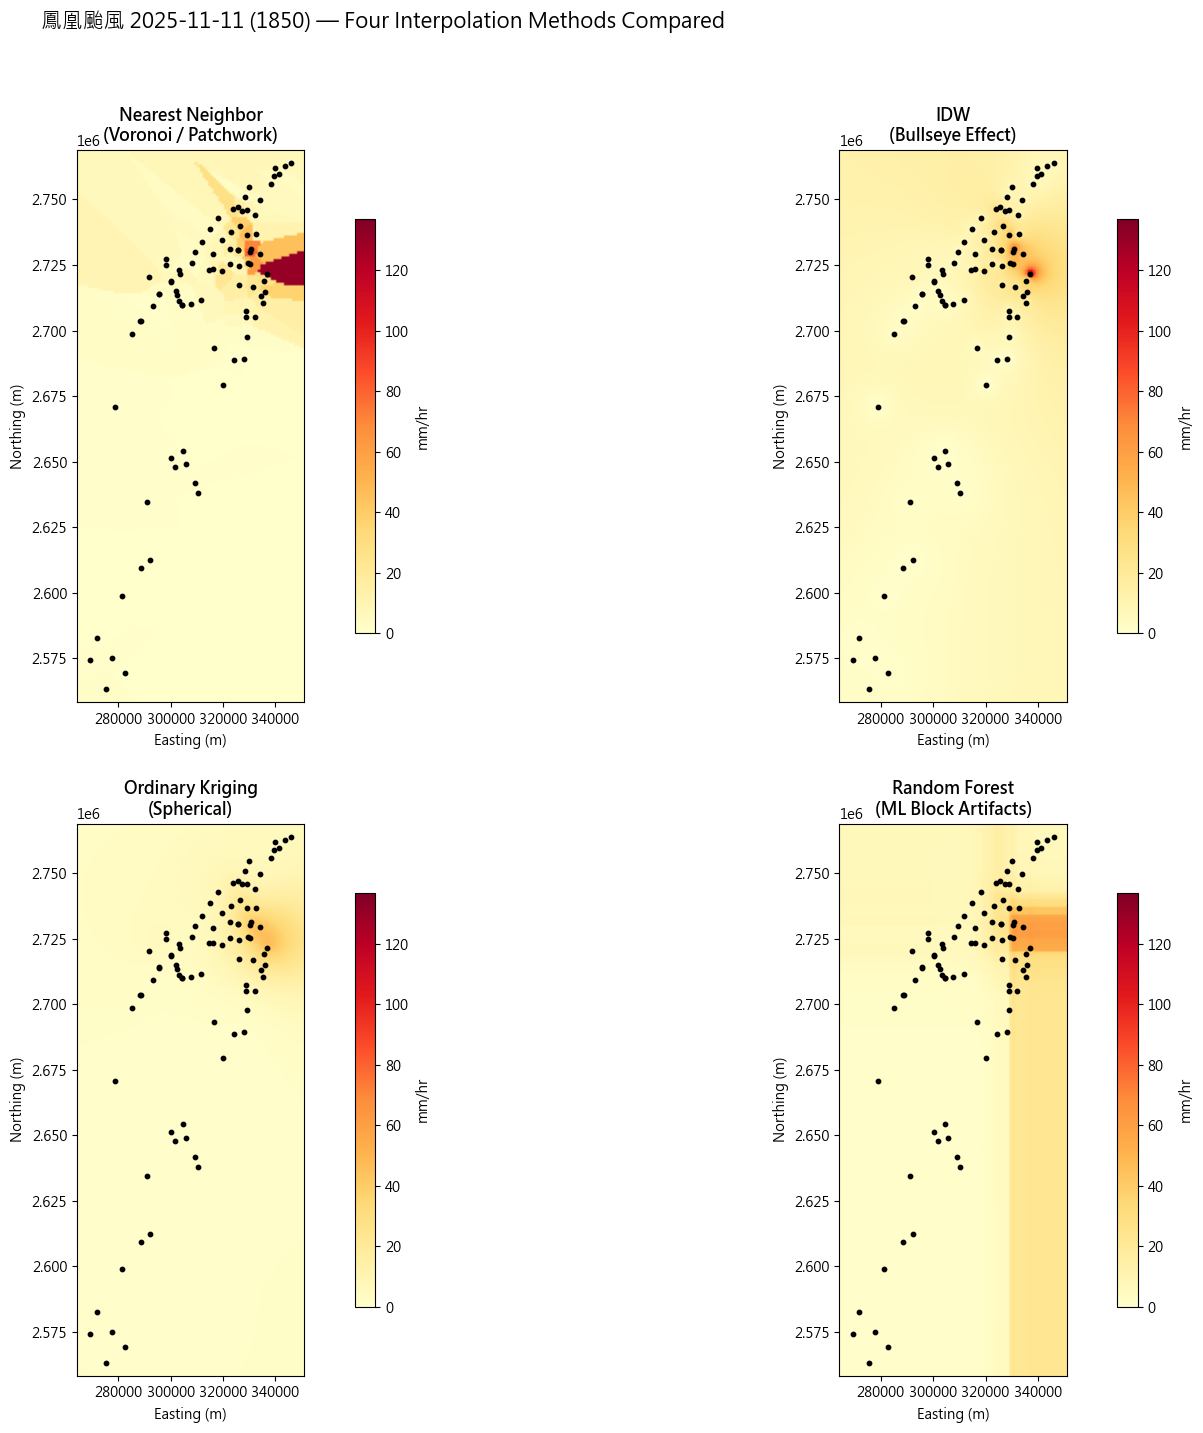

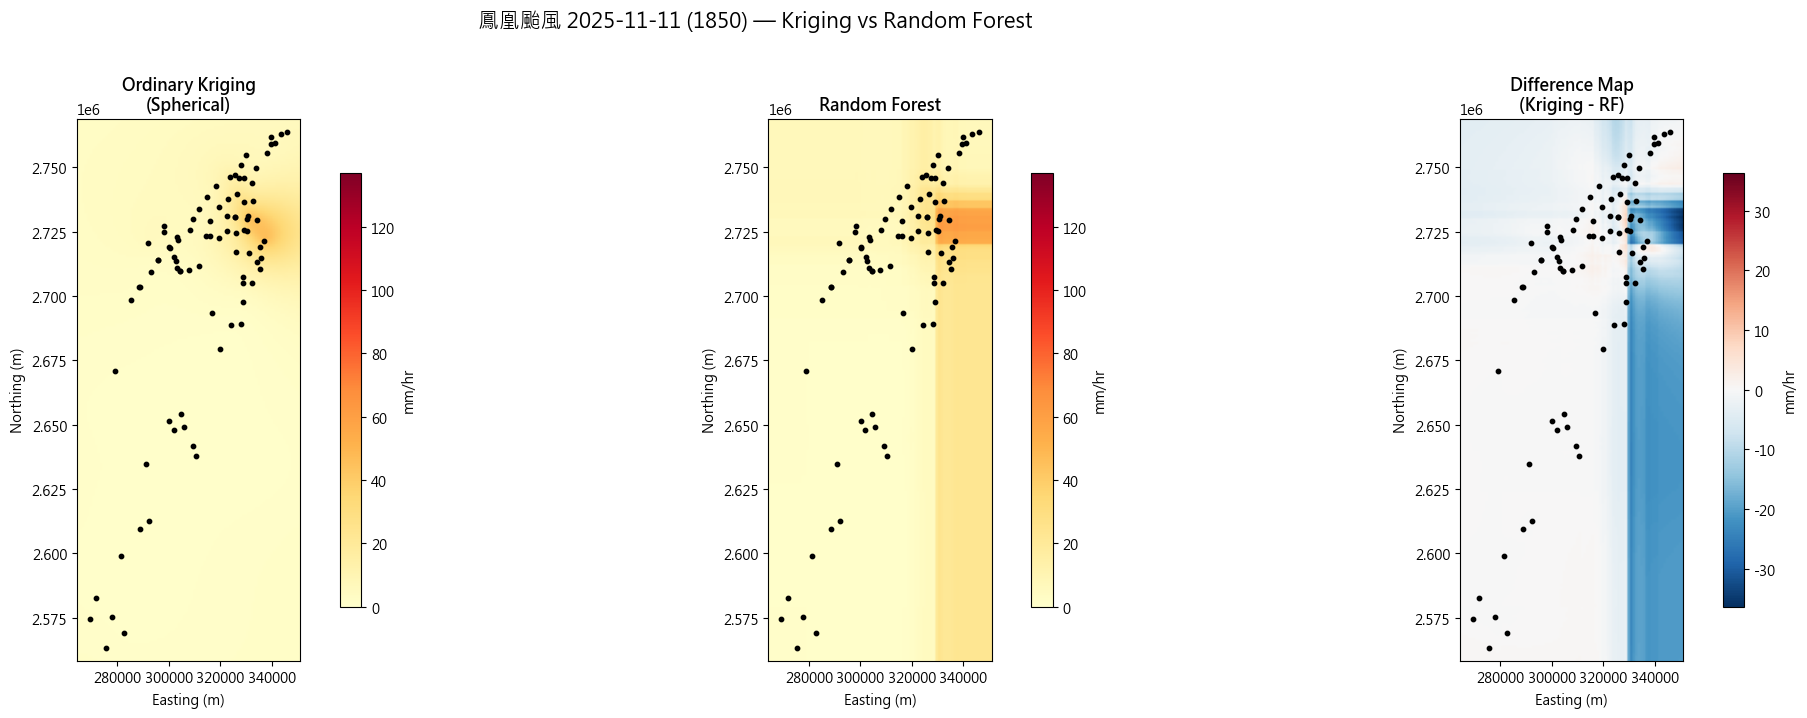


========== 豪雨事件 2025-07-28 (1710) ==========
最佳 variogram model：spherical
Grid size: 70 × 159 = 11,130 cells
✓ Kriging done in 0.1s
✓ Random Forest done in 0.1s
RF Training R²: 0.641
✓ Nearest Neighbor + IDW computed


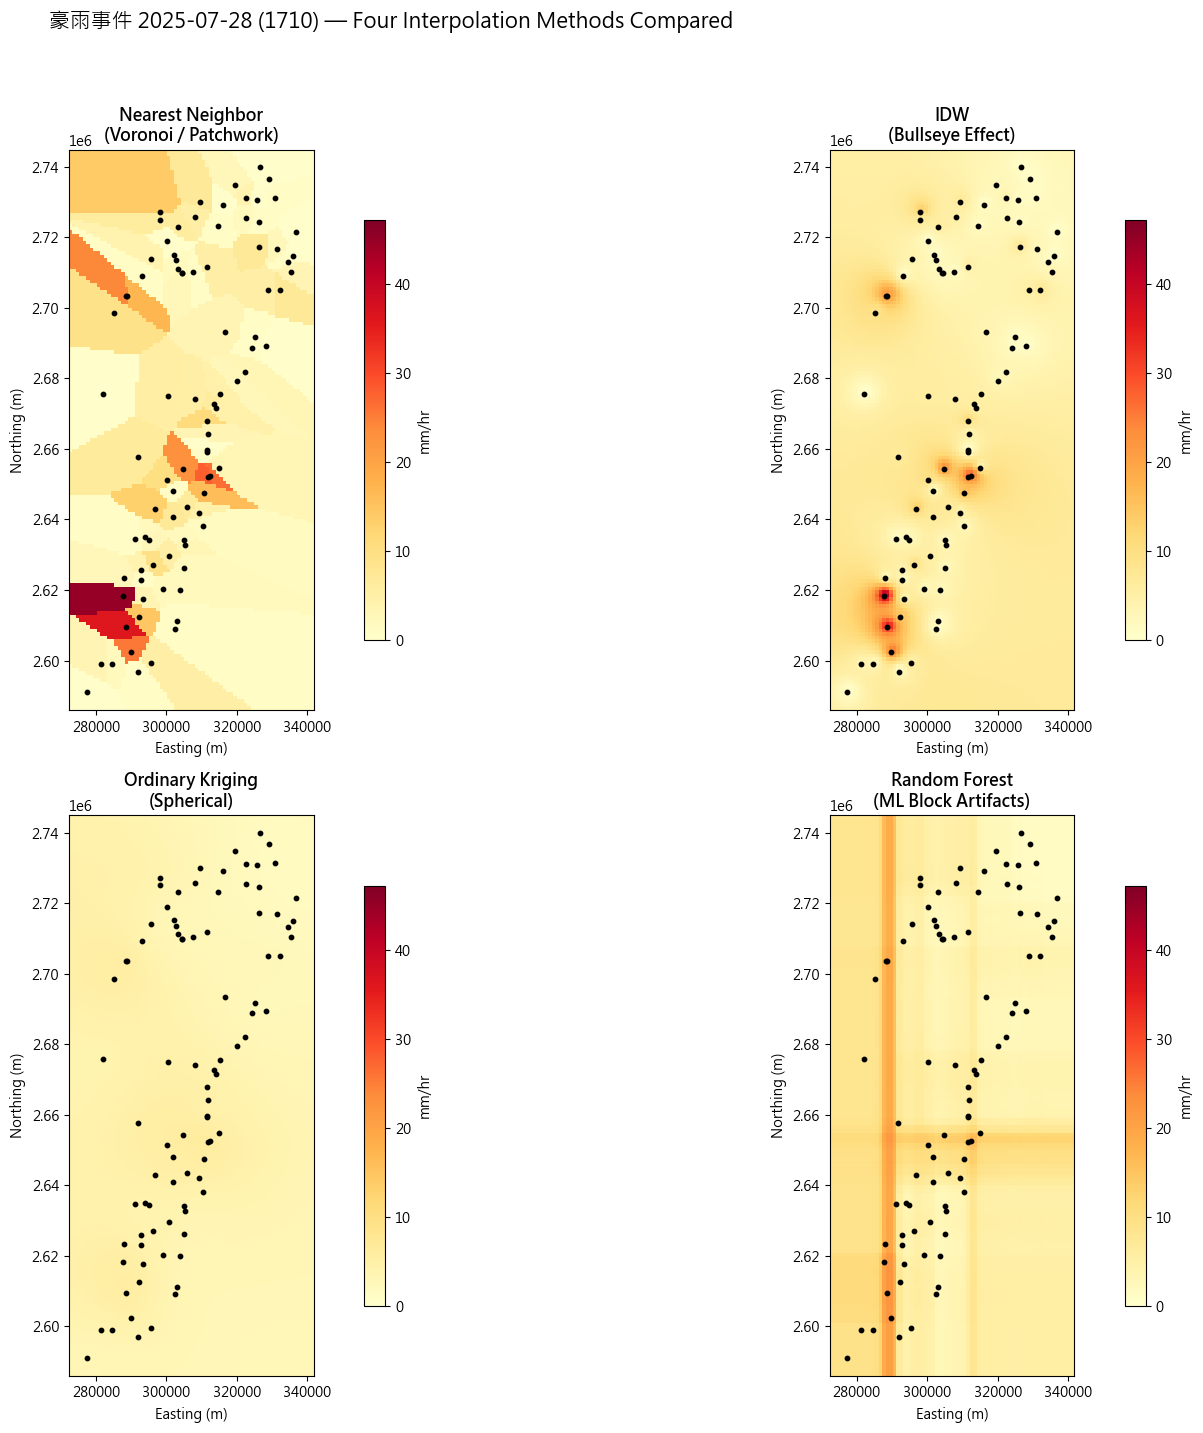

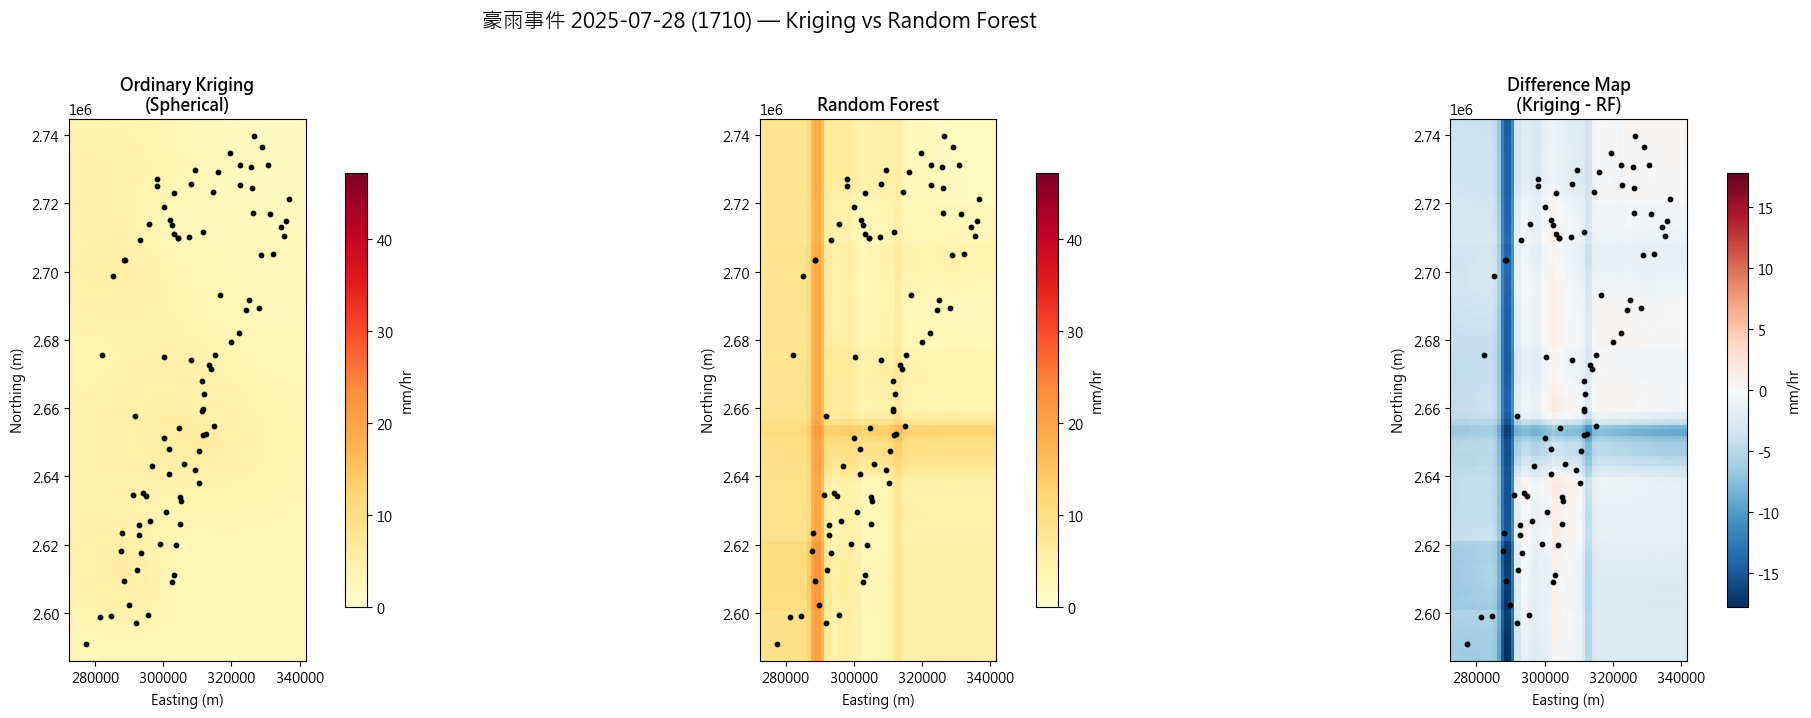

In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
from sklearn.ensemble import RandomForestRegressor
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

# =========================================================
# A2. 四種方法內插（兩個事件各做一次）
# - Nearest Neighbor
# - IDW
# - Ordinary Kriging（使用 A1 最佳 variogram model）
# - Random Forest
# - 輸出 2×2 比較圖
# - 輸出 Kriging vs RF 差異圖
# =========================================================


def run_interpolation_for_event(gdf_event, event_name, best_model, resolution=1000, buffer_m=5000):
    """
    對單一事件做四種方法內插，並繪圖比較。
    
    參數
    ----
    gdf_event : GeoDataFrame
        單一時刻、已為 EPSG:3826 的測站資料
    event_name : str
        事件名稱（用於圖名）
    best_model : str
        A1 選出的最佳 variogram model，如 'spherical' / 'exponential'
    resolution : int
        格網解析度（公尺）
    buffer_m : int
        研究區外擴距離（公尺）
    
    回傳
    ----
    result_dict : dict
        包含 x, y, z, grid_x, grid_y, z_nn, z_idw, z_kriging, ss_kriging, z_rf 等
    """

    if gdf_event.empty:
        raise ValueError(f"{event_name} 沒有資料，無法進行內插。")

    # -----------------------------------------------------
    # 1. 取 x, y, z
    # -----------------------------------------------------
    x = gdf_event.geometry.x.values
    y = gdf_event.geometry.y.values
    z = gdf_event["rain_1hr"].values.astype(float)

    # Kriging 使用 log-space
    z_log = np.log1p(z)

    # -----------------------------------------------------
    # 2. 建立格網
    # -----------------------------------------------------
    x_min = x.min() - buffer_m
    x_max = x.max() + buffer_m
    y_min = y.min() - buffer_m
    y_max = y.max() + buffer_m

    grid_x = np.arange(x_min, x_max, resolution)
    grid_y = np.arange(y_min, y_max, resolution)
    grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)

    print(f"\n========== {event_name} ==========")
    print(f"最佳 variogram model：{best_model}")
    print(f"Grid size: {len(grid_x)} × {len(grid_y)} = {len(grid_x) * len(grid_y):,} cells")

    # -----------------------------------------------------
    # 3. Ordinary Kriging（使用最佳 model，自動擬合）
    # -----------------------------------------------------
    t0 = time.time()
    OK = OrdinaryKriging(
        x, y, z_log,
        variogram_model=best_model,
        verbose=False,
        enable_plotting=False,
        nlags=10
    )
    z_kriging_log, ss_kriging_log = OK.execute("grid", grid_x, grid_y)
    z_kriging = np.expm1(z_kriging_log)
    z_kriging = np.asarray(z_kriging, dtype=float)
    z_kriging[z_kriging < 0] = 0
    ss_kriging = np.asarray(ss_kriging_log, dtype=float)
    print(f"✓ Kriging done in {time.time() - t0:.1f}s")

    # -----------------------------------------------------
    # 4. Random Forest
    # -----------------------------------------------------
    X_train = np.column_stack([x, y])
    y_train = z

    rf = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=3,
        random_state=42
    )
    rf.fit(X_train, y_train)

    X_grid = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])

    t0 = time.time()
    z_rf = rf.predict(X_grid).reshape(grid_xx.shape)
    z_rf = np.asarray(z_rf, dtype=float)
    z_rf[z_rf < 0] = 0
    print(f"✓ Random Forest done in {time.time() - t0:.1f}s")
    print(f"RF Training R²: {rf.score(X_train, y_train):.3f}")

    # -----------------------------------------------------
    # 5. Nearest Neighbor
    # -----------------------------------------------------
    nn_interp = NearestNDInterpolator(list(zip(x, y)), z)
    z_nn = nn_interp(grid_xx, grid_yy)
    z_nn = np.asarray(z_nn, dtype=float)

    # -----------------------------------------------------
    # 6. IDW
    # -----------------------------------------------------
    pts = np.column_stack([x, y])
    grid_pts = np.column_stack([grid_xx.ravel(), grid_yy.ravel()])
    dists = cdist(grid_pts, pts)
    dists[dists < 1] = 1  # 避免除以零
    power = 2
    weights = 1.0 / (dists ** power)
    z_idw = ((weights @ z) / weights.sum(axis=1)).reshape(grid_xx.shape)
    z_idw = np.asarray(z_idw, dtype=float)

    print("✓ Nearest Neighbor + IDW computed")

    # -----------------------------------------------------
    # 7. 四方法 2×2 比較圖
    # -----------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    vmax = max(np.nanmax(z_nn), np.nanmax(z_idw), np.nanmax(z_kriging), np.nanmax(z_rf), np.nanmax(z)) * 1.05

    methods = [
        ('Nearest Neighbor\n(Voronoi / Patchwork)', z_nn),
        ('IDW\n(Bullseye Effect)', z_idw),
        (f'Ordinary Kriging\n({best_model.capitalize()})', z_kriging),
        ('Random Forest\n(ML Block Artifacts)', z_rf),
    ]

    for ax, (title, data) in zip(axes.flatten(), methods):
        im = ax.imshow(
            data,
            extent=[x_min, x_max, y_min, y_max],
            origin='lower',
            cmap='YlOrRd',
            vmin=0,
            vmax=vmax
        )
        ax.scatter(x, y, c='black', s=10, zorder=5)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Easting (m)')
        ax.set_ylabel('Northing (m)')
        plt.colorbar(im, ax=ax, shrink=0.75, label='mm/hr')

    plt.suptitle(f'{event_name} — Four Interpolation Methods Compared', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig(f'../output/{event_name}_four_methods.png', dpi=150, bbox_inches='tight')
    plt.show()

    # -----------------------------------------------------
    # 8. Kriging vs RF 差異圖
    # -----------------------------------------------------
    diff = z_kriging - z_rf
    diff_absmax = np.nanmax(np.abs(diff))

    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    im1 = axes[0].imshow(
        z_kriging,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax
    )
    axes[0].scatter(x, y, c='black', s=10, zorder=5)
    axes[0].set_title(f'Ordinary Kriging\n({best_model.capitalize()})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Easting (m)')
    axes[0].set_ylabel('Northing (m)')
    plt.colorbar(im1, ax=axes[0], shrink=0.8, label='mm/hr')

    im2 = axes[1].imshow(
        z_rf,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd',
        vmin=0,
        vmax=vmax
    )
    axes[1].scatter(x, y, c='black', s=10, zorder=5)
    axes[1].set_title('Random Forest', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Easting (m)')
    axes[1].set_ylabel('Northing (m)')
    plt.colorbar(im2, ax=axes[1], shrink=0.8, label='mm/hr')

    im3 = axes[2].imshow(
        diff,
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='RdBu_r',
        vmin=-diff_absmax,
        vmax=diff_absmax
    )
    axes[2].scatter(x, y, c='black', s=10, zorder=5)
    axes[2].set_title('Difference Map\n(Kriging - RF)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Easting (m)')
    axes[2].set_ylabel('Northing (m)')
    plt.colorbar(im3, ax=axes[2], shrink=0.8, label='mm/hr')

    plt.suptitle(f'{event_name} — Kriging vs Random Forest', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.savefig(f'../output/{event_name}_kriging_vs_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        "event_name": event_name,
        "x": x,
        "y": y,
        "z": z,
        "grid_x": grid_x,
        "grid_y": grid_y,
        "grid_xx": grid_xx,
        "grid_yy": grid_yy,
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "z_nn": z_nn,
        "z_idw": z_idw,
        "z_kriging": z_kriging,
        "ss_kriging": ss_kriging,
        "z_rf": z_rf,
        "rf_model": rf,
        "kriging_model": OK
    }


# =========================================================
# 對兩個事件分別執行 A2
# =========================================================
fungwong_A2 = run_interpolation_for_event(
    fungwong_t,
    "鳳凰颱風 2025-11-11 (1850)",
    best_model=fungwong_vario["best_model"],
    resolution=1000,
    buffer_m=5000
)

heavy_A2 = run_interpolation_for_event(
    heavy_t,
    "豪雨事件 2025-07-28 (1710)",
    best_model=heavy_vario["best_model"],
    resolution=1000,
    buffer_m=5000
)

#### A3. 不確定性分析

1. 對每個事件產出 **Sigma Map**：Kriging variance 視覺化（Blues colormap）
2. 寫一段 **300 字以內的比較分析**，回答：
   - 兩個事件的 Sigma Map 有什麼差異？為什麼？
   - 哪種類型的降雨事件，Kriging 的預測信心較高？
   - 如果你是指揮官，在高 variance 區域會做什麼決策？
   - Random Forest 能提供類似的不確定性資訊嗎？為什麼？

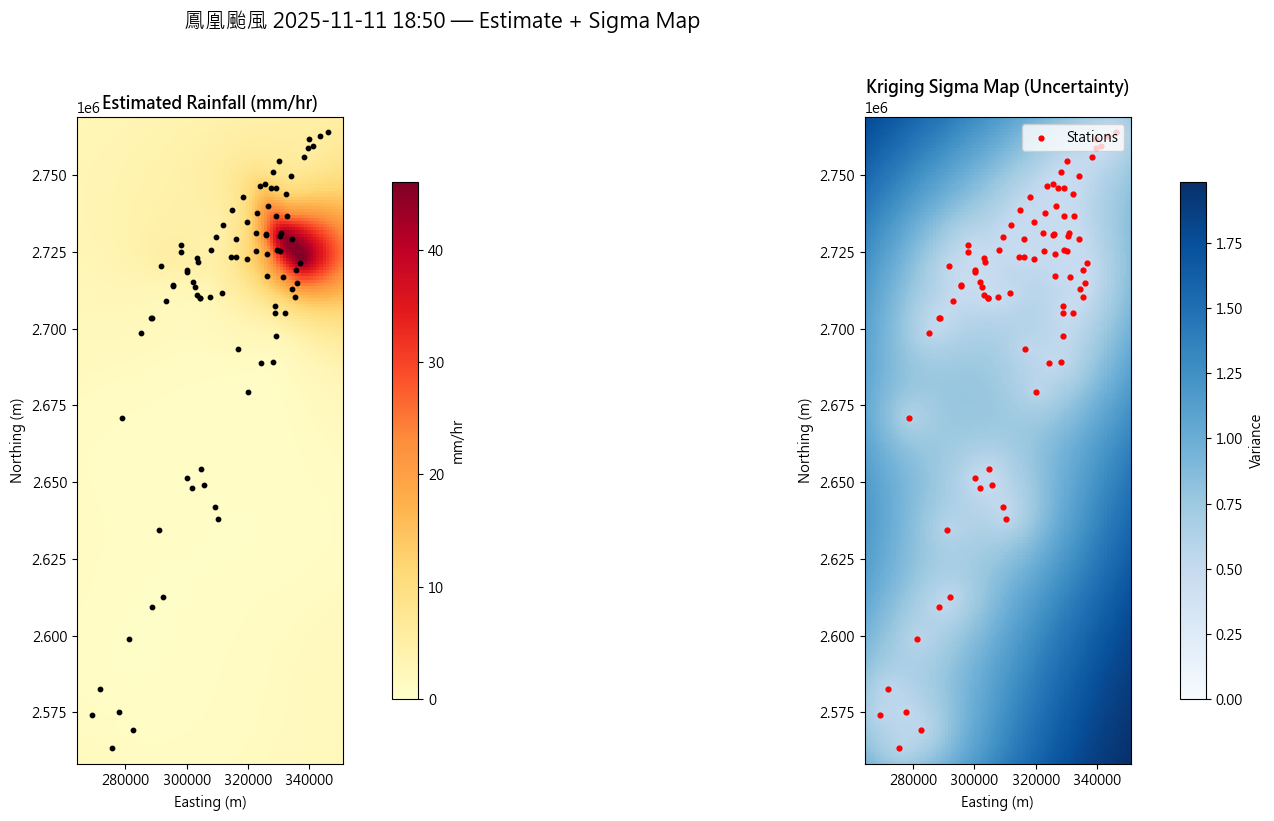

鳳凰颱風 2025-11-11 18:50 variance range: 0.4519 - 1.9847


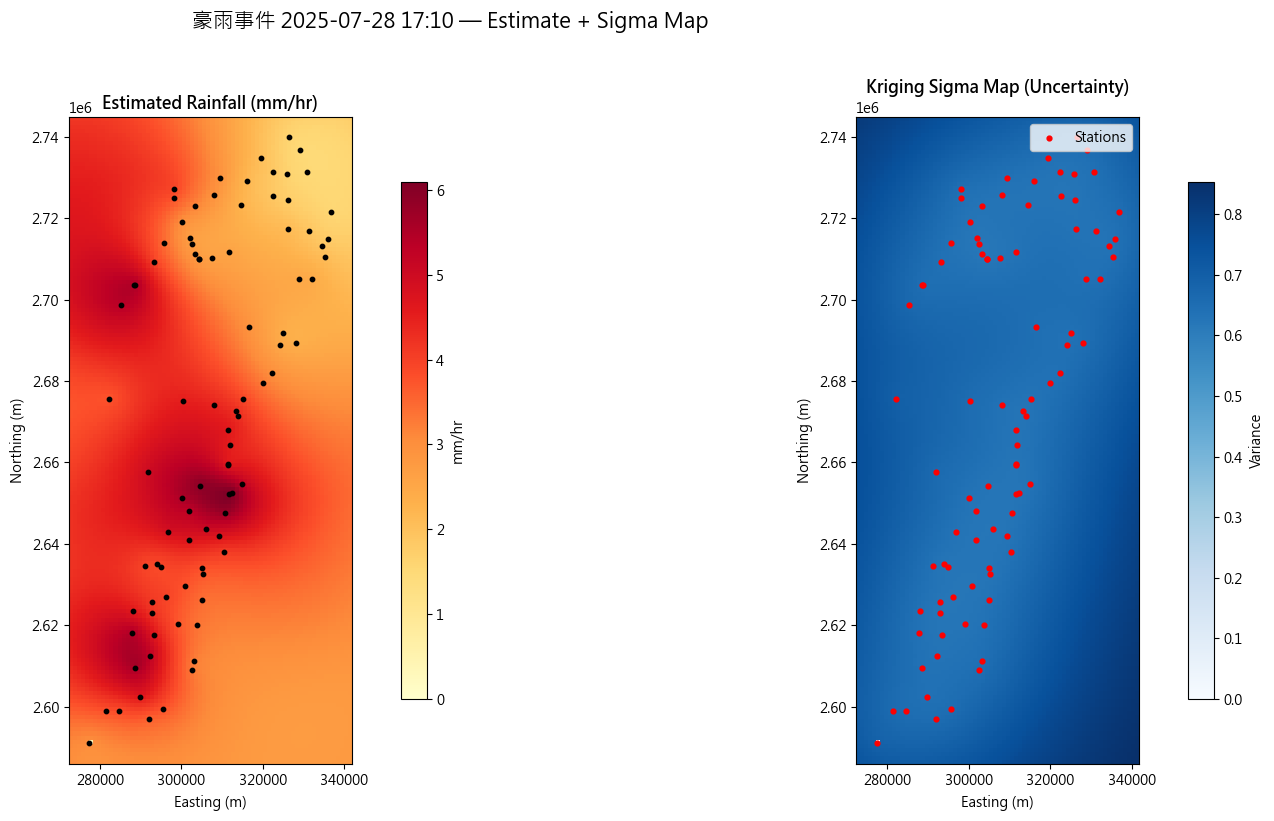

豪雨事件 2025-07-28 17:10 variance range: 0.0000 - 0.8533


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# A3. 不確定性分析
# 1. 對每個事件產出 Sigma Map（Kriging variance, Blues colormap）
# =========================================================

def plot_sigma_map(result_dict, event_name, save_fig=True):
    """
    依據 A2 輸出結果繪製 Sigma Map
    
    參數
    ----
    result_dict : dict
        A2 回傳的結果字典，需包含：
        x, y, x_min, x_max, y_min, y_max, z_kriging, ss_kriging
    event_name : str
        事件名稱
    save_fig : bool
        是否存圖
    
    回傳
    ----
    None
    """
    x = result_dict["x"]
    y = result_dict["y"]
    x_min = result_dict["x_min"]
    x_max = result_dict["x_max"]
    y_min = result_dict["y_min"]
    y_max = result_dict["y_max"]
    z_kriging = result_dict["z_kriging"]
    ss_kriging = result_dict["ss_kriging"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # 左圖：Kriging rainfall estimate
    im1 = axes[0].imshow(
        z_kriging,
        extent=[x_min, x_max, y_min, y_max],
        origin="lower",
        cmap="YlOrRd",
        vmin=0
    )
    axes[0].scatter(x, y, c="black", s=10, zorder=5)
    axes[0].set_title("Estimated Rainfall (mm/hr)", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("Easting (m)")
    axes[0].set_ylabel("Northing (m)")
    plt.colorbar(im1, ax=axes[0], shrink=0.8, label="mm/hr")

    # 右圖：Sigma Map（Kriging variance）
    im2 = axes[1].imshow(
        ss_kriging,
        extent=[x_min, x_max, y_min, y_max],
        origin="lower",
        cmap="Blues",
        vmin=0
    )
    axes[1].scatter(x, y, c="red", s=12, zorder=5, label="Stations")
    axes[1].set_title("Kriging Sigma Map (Uncertainty)", fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Easting (m)")
    axes[1].set_ylabel("Northing (m)")
    axes[1].legend(loc="upper right")
    plt.colorbar(im2, ax=axes[1], shrink=0.8, label="Variance")

    plt.suptitle(f"{event_name} — Estimate + Sigma Map", fontsize=15, y=1.02)
    plt.tight_layout()

    if save_fig:
        safe_name = event_name.replace(" ", "_").replace(":", "-")
        plt.savefig(f"../output/{safe_name}_sigma_map.png", dpi=150, bbox_inches="tight")

    plt.show()

    print(f"{event_name} variance range: {np.nanmin(ss_kriging):.4f} - {np.nanmax(ss_kriging):.4f}")


# =========================================================
# 對兩個事件分別繪製 Sigma Map
# =========================================================
plot_sigma_map(
    fungwong_A2,
    "鳳凰颱風 2025-11-11 18:50",
    save_fig=True
)

plot_sigma_map(
    heavy_A2,
    "豪雨事件 2025-07-28 17:10",
    save_fig=True
)

<div style="font-size: 16px; line-height: 1.7;">

- **Sigma Map 差異**：鳳凰颱風事件的 Kriging variance 較高，範圍約為 **0.452–1.985**，且高值區分布較廣，顯示在極端降雨核心區與測站較稀疏區域，模型的不確定性明顯上升；相較之下，豪雨事件的 variance 約為 **0.000–0.853**，整體較低且空間變化較平滑，表示該事件的雨量場較容易被現有測站網支撐與描述。  
- **哪種事件信心較高**：就本次結果而言，**豪雨事件**的 Kriging 預測信心較高，因為其 Sigma Map 整體值較低，代表空間插值時對未知區域的估計較穩定；鳳凰颱風則因局部極端值突出，空間變異更劇烈，因此不確定性較大。  
- **高 variance 區域的決策**：若我是指揮官，會將高 variance 區視為「高風險但仍需確認」的區域，優先加派臨時感測器、交叉參考雷達與鄰近測站資訊，必要時先發布預警或提高警戒層級，而不會只依賴單一插值圖直接下最終決策。  
- **RF 能否提供類似資訊**：**Random Forest 不能原生提供與 Kriging Sigma Map 等價的不確定性資訊**，因為它本質上只學習座標與雨量之間的映射關係，沒有像 Kriging 一樣顯式建模空間自相關；即使可用 bootstrap 或多棵樹分散程度近似不確定性，那也只是模型穩定度指標，並不是真正的空間變異數。  

</div>

#### A4. GeoTIFF 輸出（擇一事件即可）

1. 將 Kriging 結果儲存為 `kriging_rainfall.tif`（EPSG:3826）
2. 將 Kriging variance 儲存為 `kriging_variance.tif`（EPSG:3826）
3. 將 RF 結果儲存為 `rf_rainfall.tif`（EPSG:3826）
4. **注意 y 軸翻轉**：numpy row 0 = south → GeoTIFF row 0 = north（需 `np.flipud()`）

In [ ]:
# =========================================================
# A4. GeoTIFF 輸出（擇一事件即可）
# - 將結果輸出到 ../output 資料夾
# - 這裡使用「豪雨事件 2025-07-28 17:10」
# - 輸出：
#   1. kriging_rainfall.tif
#   2. kriging_variance.tif
#   3. rf_rainfall.tif
# - 注意：寫入前要 np.flipud()
# =========================================================

import os
import numpy as np
import rasterio
from rasterio.transform import from_bounds

# ---------------------------------------------------------
# 1. 選擇要輸出的事件：豪雨事件 2025-07-28 17:10
#    請確認你前面 A2 的結果變數名稱就是 heavy_A2
# ---------------------------------------------------------
export_result = heavy_A2

# ---------------------------------------------------------
# 2. 建立輸出資料夾
# ---------------------------------------------------------
output_dir = "..\\output"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# 3. 取出必要資訊
# ---------------------------------------------------------
x_min = export_result["x_min"]
x_max = export_result["x_max"]
y_min = export_result["y_min"]
y_max = export_result["y_max"]

z_kriging = export_result["z_kriging"]
ss_kriging = export_result["ss_kriging"]
z_rf = export_result["z_rf"]

# ---------------------------------------------------------
# 4. 建立 GeoTIFF transform
# ---------------------------------------------------------
transform = from_bounds(
    x_min, y_min, x_max, y_max,
    width=z_kriging.shape[1],
    height=z_kriging.shape[0]
)

# ---------------------------------------------------------
# 5. 寫 GeoTIFF 的 helper function
# ---------------------------------------------------------
def save_geotiff(data, out_path, crs="EPSG:3826", nodata=-9999):
    """
    將 2D numpy array 儲存為 GeoTIFF
    注意：
    - numpy row 0 = south
    - GeoTIFF row 0 = north
    所以需先 np.flipud()
    """
    arr = np.asarray(data, dtype=np.float32)
    arr = np.flipud(arr)  # 關鍵：上下翻轉
    arr = np.where(np.isfinite(arr), arr, nodata).astype(np.float32)

    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=arr.shape[0],
        width=arr.shape[1],
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=nodata
    ) as dst:
        dst.write(arr, 1)

    print(f"✓ Saved: {out_path}")

# ---------------------------------------------------------
# 6. 輸出三個 GeoTIFF
# ---------------------------------------------------------
kriging_rainfall_path = os.path.join(output_dir, "kriging_rainfall.tif")
kriging_variance_path = os.path.join(output_dir, "kriging_variance.tif")
rf_rainfall_path = os.path.join(output_dir, "rf_rainfall.tif")

save_geotiff(z_kriging, kriging_rainfall_path)
save_geotiff(ss_kriging, kriging_variance_path)
save_geotiff(z_rf, rf_rainfall_path)

print("\nA4 完成：已將豪雨事件 2025-07-28 17:10 的 GeoTIFF 輸出到 ../output")

✓ Saved: ..\output\kriging_rainfall.tif
✓ Saved: ..\output\kriging_variance.tif
✓ Saved: ..\output\rf_rainfall.tif

A4 完成：已將豪雨事件 2025-07-28 17:10 的 GeoTIFF 輸出到 ../output


### A5. (加分) 跨事件綜合比較

- 將兩事件的 Variogram 參數整理成表格：

| 參數 | 事件 1 | 事件 2 | 差異原因 |
|------|--------|--------|----------|
| Sill | | | |
| Range | | | |
| Nugget | | | |
| Best Model | | | |

- 回答：「如果你只能用一組 Variogram 參數套用到未來所有事件，你會怎麼選？為什麼這樣做有風險？」

In [ ]:
# =========================================================
# A5. (加分) 跨事件綜合比較
# - 將兩事件的 Variogram 參數整理成表格
# - 加上「差異原因」欄位
# - 確保表格中文字完整顯示，不被 ... 截斷
# =========================================================

import pandas as pd
import textwrap

# 讓 pandas 不截斷欄位內容
pd.set_option("display.max_colwidth", None)

# ---------------------------------------------------------
# 1. 取兩事件最佳 variogram 結果
# ---------------------------------------------------------
fungwong_best = fungwong_vario["results_df"].iloc[0].copy()
heavy_best = heavy_vario["results_df"].iloc[0].copy()

# 事件名稱
event1_name = "鳳凰颱風 2025-11-11 18:50"
event2_name = "豪雨事件 2025-07-28 17:10"

# ---------------------------------------------------------
# 2. 長文字自動換行函式
# ---------------------------------------------------------
def wrap_text(text, width=28):
    return "\n".join(textwrap.wrap(str(text), width=width))

# ---------------------------------------------------------
# 3. 組成 A5 表格
# ---------------------------------------------------------
a5_compare_df = pd.DataFrame({
    "參數": ["Sill", "Range", "Nugget", "Best Model"],
    "事件 1": [
        round(float(fungwong_best["sill"]), 3),
        round(float(fungwong_best["range_km"]), 3),
        round(float(fungwong_best["nugget"]), 3),
        fungwong_best["model"]
    ],
    "事件 2": [
        round(float(heavy_best["sill"]), 3),
        round(float(heavy_best["range_km"]), 3),
        round(float(heavy_best["nugget"]), 3),
        heavy_best["model"]
    ],
    "差異原因": [
        "Sill 反映整體空間變異強度；較大者通常代表事件雨量起伏更強、極端值或區域差異更明顯。鳳凰颱風事件較大，表示其整體雨量空間變異較強，可能與局部極端降雨更明顯有關。",
        "Range 反映空間相關可延伸多遠；較大者代表降雨場較具區域一致性，較小者代表局部性更強。鳳凰颱風事件較大，表示空間相關延伸得更遠，降雨分布可能較具區域一致性。",
        "Nugget 反映短距離變異與量測噪音；較大者可能表示微尺度降雨差異更強，或儀器/局部效應較明顯。豪雨事件較大，表示短距離變異較強，或局部微尺度降雨與量測誤差影響較明顯。",
        "Best Model 若不同，表示兩事件的空間結構未必相同，不同降雨型態可能更適合不同 variogram 函數形式；若相同，則代表兩事件在主要空間結構上有一定相似性。"
    ]
})

# 對「差異原因」做手動換行
a5_compare_df["差異原因"] = a5_compare_df["差異原因"].apply(lambda x: wrap_text(x, width=28))

print("========== A5 跨事件綜合比較表 ==========")

display(
    a5_compare_df.style
    .set_properties(**{
        "white-space": "pre-wrap",   # 保留換行
        "text-align": "left",
        "vertical-align": "top"
    })
    .set_properties(subset=["差異原因"], **{
        "width": "420px",
        "min-width": "420px",
        "max-width": "420px"
    })
    .set_properties(subset=["參數"], **{
        "width": "110px",
        "min-width": "110px"
    })
    .set_properties(subset=["事件 1", "事件 2"], **{
        "width": "120px",
        "min-width": "120px"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]},
        {"selector": "td", "props": [("font-size", "14px")]},
        {"selector": "table", "props": [("table-layout", "fixed"), ("width", "100%")]}
    ])
)

# ---------------------------------------------------------
# 4. 若只能選一組 variogram 參數，會怎麼選？
# ---------------------------------------------------------
print("\n[如果只能用一組 Variogram 參數套用到未來所有事件，我會怎麼選？]")
if fungwong_best["model"] == heavy_best["model"]:
    print(
        f"若只能選一組，我會優先考慮使用兩事件共同出現的 {fungwong_best['model']} model，"
        "並搭配較中間、較保守的 sill、range、nugget 作為通用參數，"
        "以避免模型過度偏向單一事件特性。"
    )
else:
    print(
        "若只能選一組，我會優先選擇較穩健、較容易解釋空間結構的 variogram model，"
        "並搭配兩事件參數的折衷值作為通用設定。"
    )

print("\n[為什麼這樣做有風險？]")
print(
    "因為不同降雨事件的空間型態並不相同，若強行共用同一組 variogram 參數，"
    "可能導致某些事件被過度平滑、某些事件又被低估局部極端值，"
    "進而使 Kriging 的預測精度與不確定性判讀失真。"
)

========== A5 跨事件綜合比較表 ==========


,參數,事件 1,事件 2,差異原因
0,Sill,1.381000,0.201000,Sill 反映整體空間變異強度；較大者通常代表事件雨量起 伏更強、極端值或區域差異更明顯。鳳凰颱風事件較大，表示其 整體雨量空間變異較強，可能與局部極端降雨更明顯有關。
1,Range,107.403000,82.953000,Range 反映空間相關可延伸多遠；較大者代表降雨場較具 區域一致性，較小者代表局部性更強。鳳凰颱風事件較大，表示 空間相關延伸得更遠，降雨分布可能較具區域一致性。
2,Nugget,0.375000,0.604000,Nugget 反映短距離變異與量測噪音；較大者可能表示微 尺度降雨差異更強，或儀器/局部效應較明顯。豪雨事件較大， 表示短距離變異較強，或局部微尺度降雨與量測誤差影響較明顯 。
3,Best Model,spherical,spherical,Best Model 若不同，表示兩事件的空間結構未必相 同，不同降雨型態可能更適合不同 variogram 函數 形式；若相同，則代表兩事件在主要空間結構上有一定相似性。



[如果只能用一組 Variogram 參數套用到未來所有事件，我會怎麼選？]
若只能選一組，我會優先考慮使用兩事件共同出現的 spherical model，並搭配較中間、較保守的 sill、range、nugget 作為通用參數，以避免模型過度偏向單一事件特性。

[為什麼這樣做有風險？]
因為不同降雨事件的空間型態並不相同，若強行共用同一組 variogram 參數，可能導致某些事件被過度平滑、某些事件又被低估局部極端值，進而使 Kriging 的預測精度與不確定性判讀失真。


<div style="font-size: 14px; line-height: 1.6;">

### Part B: 期末專案提案

#### 題目
**風雨夾擊：樺加沙颱風期間花蓮避難所的綜合風險評估**

#### 組員與分工
- 葛增安（r14521804）— Data Captain
- 游常心（r14521803）— Spatial Architect
- 劉冠伶（r14521801）— AI UX Lead
- 侯言霓（r14521813）— Gemini SDK

#### 研究問題
2025/08/12 楊柳颱風期間，花蓮縣哪些避難所因坡地災害（如土石流、崩塌）與降雨的雙重風險而最需要優先撤離？

#### 資料來源
1. **115年度 1753 條土石流潛勢溪流圖**  
   - 資料名稱：[土石流潛勢溪流資料](https://data.gov.tw/dataset/7279)  
   - 格式：SHP/1753

2. **中央氣象署雨量站資料**  
   - 資料來源：[中央氣象署](https://history.colife.org.tw/#/?cd=%2F%E6%B0%A3%E8%B1%A1%2F%E4%B8%AD%E5%A4%AE%E6%B0%A3%E8%B1%A1%E7%BD%B2_%E9%9B%A8%E9%87%8F%E7%AB%99)  
   - 格式：CSV/181602

3. **植生指標 NDVI**  
   - 資料來源：[Landsat 8](https://developers.google.com/earth-engine/datasets/catalog/landsat-8?hl=zh-tw)  
   - 格式：衛星影像（災前/災後各 1 期，共 2 期）

#### 分析方法
1. **坡地災害風險分級**  
   結合土石流潛勢溪流 buffer（500、1000、2000 m）與坡度資訊，對避難所進行低、中、高風險分級評分。

2. **降雨空間分布與避難所風險評估**  
   - 找出颱風期間降雨較強的時段，以 `Past1hr` 作為分析變數。  
   - 使用 **Kriging** 預測空間降雨分布，並推估各避難所的預測降雨量。  
   - 再以 **Random Forest** 進行綜合評估，納入避難所降雨量、坡度、地形、風險分級等變數。

3. **鄉鎮尺度風險統計**  
   依據 Random Forest 預測出的避難所風險等級，套疊花蓮鄉鎮市界圖，利用 zonal statistics 統計各鄉鎮市的高風險避難所數量與其平均收容人數。

#### 內插策略
本專案採用 **Kriging 與機器學習並用** 的方式。根據本週作業結果，Kriging 能提供較穩定且合理的空間降雨分布，但其限制在於主要適合單一變數分析；因此本組將先以 Kriging 推估各避難所的預測降雨量，再透過機器學習模型加入地形、坡度與風險分級等變數，作為最終綜合評估依據。

#### Gemini SDK 使用計畫
本專案將基於 Random Forest 所預測出的避難所風險等級，整理最迫切需要關注的避難所資訊，並串接其相關雨量、坡度等變數至 [Google AI Studio](https://aistudio.google.com/apikey)，請 Gemini 針對各避難所提供撤離建議與決策支援。

#### 預期產出
1. Jupyter Notebook
2. Folium 互動地圖 / 分析圖表
3. Gemini SDK 決策建議整合
4. 防災決策建議

#### 風險評估與備案
1. **NDVI 衛星影像可能受雲覆蓋影響，無法取得 Landsat 8 合適影像**  
   **備案：**
   - 改用其他光學衛星影像，例如 Sentinel-2  
   - 以最接近 2025/08/12 前後日期的無雲影像作為替代資料

2. **楊柳颱風的雨量資料可能無法自中央氣象署網站直接取得**  
   **備案：**
   - 改從其他官方資料平台下載雨量資料  
   - 詢問老師可取得資料的其他管道  
   - 必要時改換另一個颱風事件進行研究

</div>